Quantum dynamics and matrix related functions

In [ ]:
import numpy as np
from scipy.sparse import csr_array, csr_matrix, lil_matrix, diags
from scipy.sparse.linalg import expm_multiply


class ParameterData:
    def __init__(self, U: float, J: float, nu: float, zeta: float, N: int):
        self.U = U
        self.J = J
        self.nu = nu
        self.zeta = zeta
        self.N = N
    
    def to_list(self) -> list:
        return [self.U, self.J, self.nu, self.zeta, self.N]

    def get_xi(self) -> float:
        return 3 * self.J ** 2 / (4 * self.U) / (self.N - 1 + self.nu / self.U / 2) 

    def get_tau(self) -> float:
        return np.pi / self.get_xi()

    def get_max_zeta(self) -> float:
        return self.get_xi() / 3.0

    def get_interaction_ratio(self) -> float:
        return (self.U * self.N + self.nu / 2.0) / self.J

    def set_interaction_ratios(self, int_ratio: float, nu_ratio: float):
        self.U = self.J * int_ratio / (self.N + nu_ratio / 2.0)
        self.nu = nu_ratio * self.U


class BasisData:
    def __init__(self, vectors: list, lookup: list, numbers: list):
        self.vectors = vectors
        self.lookup = lookup
        self.numbers = numbers

    def to_list(self) -> list:
        return [self.vectors, self.lookup]


class TimeData:
    def __init__(self, min_t: float, max_t: float, ticks: int):
        self.min_t = min_t
        self.max_t = max_t
        self.ticks = ticks

    def to_list(self) -> list:
        return [self.min_t, self.max_t, self.ticks]

    def to_space(self) -> list:
        return np.linspace(self.min_t, self.max_t, self.ticks)


## Returns the occupation matrices of the system as a list of sparse matrices.
def get_number_matrices_sparse(basis_vectors) -> list:
    n1 = np.array([s[0] for s in basis_vectors])
    n2 = np.array([s[1] for s in basis_vectors])
    n3 = np.array([s[2] for s in basis_vectors])
    n4 = np.array([s[3] for s in basis_vectors])
    return diags(n1), diags(n2), diags(n3), diags(n4)


def get_basis(N) -> BasisData:
    vectors = []

    for n1 in range(N + 1):
        for n2 in range(N + 1 - n1):
            for n3 in range(N + 1 - n1 - n2):
                n4 = N - n1 - n2 - n3
                vectors.append((n1, n2, n3, n4))

    lookup = {state: i for i, state in enumerate(vectors)}
    numbers = get_number_matrices_sparse(vectors)

    return BasisData(vectors, lookup, numbers)


## Returns the system's Hamiltonian as a sparse matrix.
def get_H_sparse(params: ParameterData, basis_data: BasisData) -> csr_array:
    U, J, nu, zeta, _ = params.to_list()
    basis, lookup = basis_data.to_list()

    D = len(basis)
    H = lil_matrix((D,D),dtype=complex)

    for col, (n1, n2, n3, n4) in enumerate(basis):
        imbalance = n1 + n2 + n3 - n4

        # Diagonal term
        H[col, col] += U * imbalance ** 2
        H[col, col] += nu * imbalance

        # Hopping terms
        for site in range(3):
            occ = [n1, n2, n3]
            if occ[site] > 0:
                new = occ.copy()
                new[site] -= 1
                new4 = n4 + 1
                row = lookup[(new[0], new[1], new[2], new4)]
                H[row, col] += -J * np.sqrt(occ[site]) * np.sqrt(n4 + 1)
            if n4 > 0:
                new = occ.copy()
                new[site] += 1
                new4 = n4-1
                row = lookup[(new[0], new[1], new[2], new4)]
                H[row, col] += -J * np.sqrt(new[site]) * np.sqrt(n4)


        # Rotational terms
        pairs = [(0,1), (1,2), (2,0)]
        occ = [n1, n2, n3]
        for a, b in pairs:
            if occ[b] > 0:
                new = occ.copy()
                new[a] += 1
                new[b] -= 1
                row = lookup[(new[0], new[1], new[2], n4)]
                H[row, col] += -zeta * (-1j / np.sqrt(3)) * np.sqrt(occ[a] + 1) * np.sqrt(occ[b])
            if occ[a] > 0:
                new = occ.copy()
                new[a] -= 1
                new[b] += 1
                row = lookup[(new[0], new[1], new[2], n4)]
                H[row, col] += -zeta * (1j / np.sqrt(3)) * np.sqrt(occ[a]) * np.sqrt(occ[b] + 1)

    return H.tocsr()


## Returns the state |n1 n2 n3 n4〉 in the system's occupancy basis.
def get_state(n1: int, n2: int, n3: int, n4: int, basis_data: BasisData) -> csr_matrix:
    N, D = n1 + n2+ n3 + n4, len(basis_data.vectors)
    return csr_matrix(
        ([1.0], ([basis_data.lookup[(n1, n2, n3, n4)]], [0])),
        shape = (D, 1)
    )


## Evolves [psi] from [min_t] to [max_t] using [H] in the time evolution operator.
def get_time_evolution_of(state: csr_matrix, H: csr_array, time_data: TimeData) -> csr_matrix:
    return expm_multiply(-1j * H, state, start = min_t, stop = max_t, num = ticks)


## Returns the sandwich 〈bra|operator|ket〉.
def get_expected_value_of(state, operator) -> float:
    return np.real((state.conj().T @ (operator @ state))[0,0])


## Returns the quantum dynamics of the system.
def get_dynamics(params: ParameterData, basis_data: BasisData, time_data: TimeData):
    N = params.N
    H = get_H_sparse(params, basis_data)
    psi = get_state(params.N, 0, 0, 0, basis_data)

    # Time evoled initial state
    psi_t = get_time_evolution_of(psi, H, time_data)

    # Expectation values
    N1, N2, N3, N4 = basis_data.numbers
    N1_value, N2_value, N3_value, N4_value = [], [], [], []

    for i in range(len(psi_t)):
        N1_value.append(get_expected_value_of(psi_t[i], N1) / N)
        N2_value.append(get_expected_value_of(psi_t[i], N2) / N)
        N3_value.append(get_expected_value_of(psi_t[i], N3) / N)
        N4_value.append(get_expected_value_of(psi_t[i], N4) / N)

    return N1_value, N2_value, N3_value, N4_value


## Returns the effective quantum dynamics of the system.
def get_effective_dynamics(params: ParameterData, time_data: TimeData):
    zeta = params.zeta
    xi = params.get_xi()
    
    theta = lambda t, k : t * zeta + 2.0 * (k - 1) * np.pi / 3.0
    expected_N = lambda t, k : (1.0 + 4.0 * np.cos(theta(t, k)) * (np.cos(xi * t) + np.cos(theta(t, k))))/9

    time_space = time_data.to_space()
    N1_value, N2_value, N3_value = [], [], []

    for t in time_space:
        N1_value.append(expected_N(t, 1))
        N2_value.append(expected_N(t, 2))
        N3_value.append(expected_N(t, 3))
    
    return N1_value, N2_value, N3_value

Plot setup

In [ ]:
import matplotlib.pyplot as plt

# Default figure size
figsize_x = 6
figsize_y = 3.25
figsize = (figsize_x, figsize_y)

# Fixed parameters
N = 16
J = 8.22
DEFAULT_NU_RATIO = 1.0
DY_RESONANT_INT_RATIO = 11.43

# Cache basis data
basis_data = get_basis(N)

/tmp/ipykernel_42466/703260165.py:63: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  return diags(n1), diags(n2), diags(n3), diags(n4)


Dynamics with no rotation

/tmp/ipykernel_42466/1447753124.py:20: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=figsize, layout="constrained")


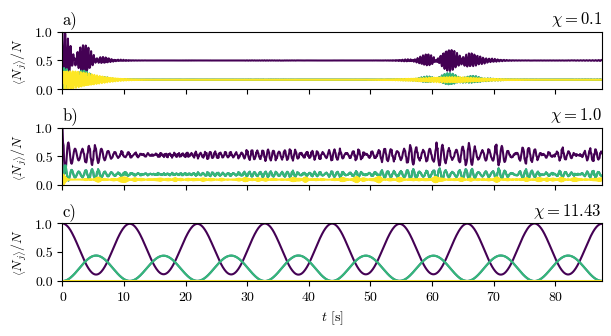

In [ ]:
# Setup parameters
params = ParameterData(0.0, J, 0.0, 0.0, N)
params.set_interaction_ratios(DY_RESONANT_INT_RATIO, DEFAULT_NU_RATIO)

# Setup time data
tau = params.get_tau()
min_t = 0.0
max_t = 16.0 * tau
ticks = 1000
time_data = TimeData(min_t, max_t, ticks)
time_space = time_data.to_space()


# Setup colors and fonts
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(np.linspace(0, 1, 4)))
plt.rcParams["font.family"] = "cmr10"
plt.rcParams["mathtext.fontset"] = "cm"

# Setup axis
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=figsize, layout="constrained")

ax0.set_xlim(min_t, max_t)
ax1.set_xlim(min_t, max_t)
ax2.set_xlim(min_t, max_t)

ax0.set_ylim(0.0, 1.0)
ax1.set_ylim(0.0, 1.0)
ax2.set_ylim(0.0, 1.0)

ax0.set_ylabel(r"$\left\langle N_{j}\right\rangle /N$")
ax1.set_ylabel(r"$\left\langle N_{j}\right\rangle /N$")
ax2.set_ylabel(r"$\left\langle N_{j}\right\rangle /N$")


# Plot for interaction ratio << 1
params.set_interaction_ratios(0.1, 1.0)
N1_value, N2_value, N3_value, N4_value = get_dynamics(params, basis_data, time_data)

# Store data
expected_values_ll_1 = [N1_value.copy(), N2_value.copy(), N3_value.copy(), N4_value.copy()]

ax0.set_title("a)", loc="left")
ax0.set_title(f"$\\chi={params.get_interaction_ratio()}$", loc="right")

ax0.plot(time_space, N1_value, label="$N_{1}$")
ax0.plot(time_space, N2_value, label="$N_{2}$")
ax0.plot(time_space, N3_value, label="$N_{3}$")
ax0.plot(time_space, N4_value, label="$N_{4}$")


# Plot for interaction ratio ~ 1
params.set_interaction_ratios(1.0, 1.0)
N1_value, N2_value, N3_value, N4_value = get_dynamics(params, basis_data, time_data)

# Store data
expected_values_sim_1 = [N1_value.copy(), N2_value.copy(), N3_value.copy(), N4_value.copy()]

ax1.set_title("b)", loc="left")
ax1.set_title(f"$\\chi={params.get_interaction_ratio()}$", loc="right")

ax1.plot(time_space, N1_value, label="$N_{1}$")
ax1.plot(time_space, N2_value, label="$N_{2}$")
ax1.plot(time_space, N3_value, label="$N_{3}$")
ax1.plot(time_space, N4_value, label="$N_{4}$")


# Plot for interaction ratio >> 1
params.set_interaction_ratios(DY_RESONANT_INT_RATIO, 1.0)
N1_value, N2_value, N3_value, N4_value = get_dynamics(params, basis_data, time_data)

# Store data
expected_values_gg_1 = [N1_value.copy(), N2_value.copy(), N3_value.copy(), N4_value.copy()]

ax2.set_title("c)", loc="left")
ax2.set_title(f"$\\chi={params.get_interaction_ratio()}$", loc="right")
ax2.set_xlabel(r"$t$ [s]")

ax2.plot(time_space, N1_value, label="$N_{1}$")
ax2.plot(time_space, N2_value, label="$N_{2}$")
ax2.plot(time_space, N3_value, label="$N_{3}$")
ax2.plot(time_space, N4_value, label="$N_{4}$")


# Save plot
plt.savefig("../images/plots/pop_dynamics_no_rotation", dpi=500)


Center to outer site imbalance dynamics with no rotation

/tmp/ipykernel_42466/2068884243.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=figsize, layout="constrained")


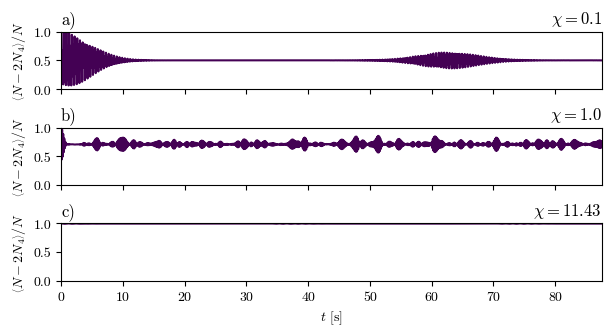

In [ ]:
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=figsize, layout="constrained")

ax0.set_xlim(min_t, max_t)
ax1.set_xlim(min_t, max_t)
ax2.set_xlim(min_t, max_t)

ax0.set_ylim(0.0, 1.0)
ax1.set_ylim(0.0, 1.0)
ax2.set_ylim(0.0, 1.0)

ax0.set_ylabel(r"$\left\langle N - 2N_{4}\right\rangle /N$")
ax1.set_ylabel(r"$\left\langle N - 2N_{4}\right\rangle /N$")
ax2.set_ylabel(r"$\left\langle N - 2N_{4}\right\rangle /N$")


# Plot for interaction ratio << 1
params.set_interaction_ratios(0.1, 1.0)
N1_value, N2_value, N3_value, N4_value = expected_values_ll_1

ax0.set_title("a)", loc="left")
ax0.set_title(f"$\\chi={params.get_interaction_ratio()}$", loc="right")
ax0.plot(time_space, [a + b + c - 2*d for a,b,c,d in zip(N1_value, N2_value, N3_value, N4_value)])


# Plot for interaction ratio ~ 1
params.set_interaction_ratios(1.0, 1.0)
N1_value, N2_value, N3_value, N4_value = expected_values_sim_1

ax1.set_title("b)", loc="left")
ax1.set_title(f"$\\chi={params.get_interaction_ratio()}$", loc="right")
ax1.plot(time_space, [a + b + c - 2*d for a,b,c,d in zip(N1_value, N2_value, N3_value, N4_value)])


# Plot for interaction ratio >> 1
params.set_interaction_ratios(DY_RESONANT_INT_RATIO, 1.0)
N1_value, N2_value, N3_value, N4_value = expected_values_gg_1

ax2.set_title("c)", loc="left")
ax2.set_title(f"$\\chi={params.get_interaction_ratio()}$", loc="right")
ax2.plot(time_space, [a + b + c - 2*d for a,b,c,d in zip(N1_value, N2_value, N3_value, N4_value)])

ax2.set_xlabel(r"$t$ [s]")


# Save figure
plt.savefig("../images/plots/pop_dynamics_no_rotation_diff", dpi=500)

Resonant regime numerical vs effective comparison

/tmp/ipykernel_42466/2338458290.py:7: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax0 = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=(figsize_x, figsize_y / 2), layout="constrained")


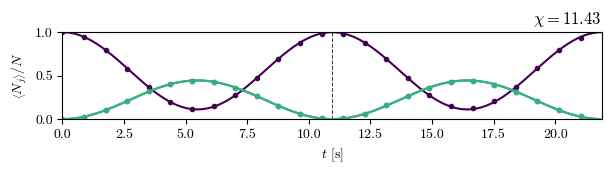

In [ ]:
P = 4
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(np.linspace(0, 1, P)))
plt.rcParams["font.family"] = "cmr10"
plt.rcParams["mathtext.fontset"] = "cm"

# Setup axis
fig, ax0 = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=(figsize_x, figsize_y / 2), layout="constrained")

ax0.set_xlim(min_t, max_t / 4.0)
ax0.set_ylim(0.0, 1.0)

ax0.set_ylabel(r"$\left\langle N_{j} \right\rangle /N$")
ax0.set_xlabel(r"$t$ [s]")

ax0.axvline(x=2*tau, linestyle="dashed", linewidth=.75, alpha=.75, color="black")
ax0.set_title(f"$\\chi={params.get_interaction_ratio()}$", loc="right")

# Plot stored data
params.set_interaction_ratios(11.44, 1.0)

N1_value, N2_value, N3_value = get_effective_dynamics(params, time_data)
ax0.plot(time_space[0:250], N1_value[0:250])
ax0.plot(time_space[0:250], N2_value[0:250])
ax0.plot(time_space[0:250], N3_value[0:250])

N1_value, N2_value, N3_value, N4_value = expected_values_gg_1
ax0.scatter(time_space[0:250:10], N1_value[0:250:10], marker=".")
ax0.scatter(time_space[0:250:10], N2_value[0:250:10], marker=".")
ax0.scatter(time_space[0:250:10], N3_value[0:250:10], marker=".")

# Save figure
plt.savefig("../images/plots/resonant_regime_num_vs_eff_comparison", dpi=500)

Dynamics with rotation

/tmp/ipykernel_42466/3931671184.py:23: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=figsize, layout="constrained")


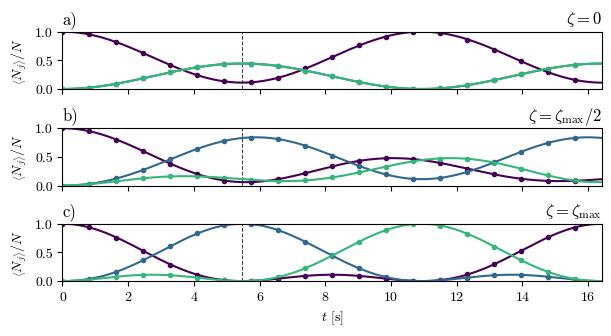

In [ ]:
# Setup parameters
params = ParameterData(0.0, J, 0.0, 0.0, N)
params.set_interaction_ratios(DY_RESONANT_INT_RATIO, DEFAULT_NU_RATIO)

# Maximum rotation
zeta_max = params.get_max_zeta()

# Setup time data
tau = params.get_tau()
min_t = 0.0
max_t = 3.0 * tau
ticks = 1000
time_data = TimeData(min_t, max_t, ticks)
time_space = time_data.to_space()


# Setup colors and fonts
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(np.linspace(0, 1, 4)))
plt.rcParams["font.family"] = "cmr10"
plt.rcParams["mathtext.fontset"] = "cm"

# Setup axis
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=figsize, layout="constrained")

ax0.axvline(x=tau, linestyle="dashed", linewidth=.75, alpha=.75, color="black")
ax1.axvline(x=tau, linestyle="dashed", linewidth=.75, alpha=.75, color="black")
ax2.axvline(x=tau, linestyle="dashed", linewidth=.75, alpha=.75, color="black")

ax0.set_xlim(min_t, max_t)
ax1.set_xlim(min_t, max_t)
ax2.set_xlim(min_t, max_t)

ax0.set_ylim(0.0, 1.0)
ax1.set_ylim(0.0, 1.0)
ax2.set_ylim(0.0, 1.0)

ax0.set_ylabel(r"$\left\langle N_{j}\right\rangle /N$")
ax1.set_ylabel(r"$\left\langle N_{j}\right\rangle /N$")
ax2.set_ylabel(r"$\left\langle N_{j}\right\rangle /N$")


# No rotation
params.zeta = 0.0

# Analytical
N1_value, N2_value, N3_value = get_effective_dynamics(params, time_data)

ax0.plot(time_space, N1_value)
ax0.plot(time_space, N2_value)
ax0.plot(time_space, N3_value)

# Numerical
N1_value, N2_value, N3_value, N4_value = get_dynamics(params, basis_data, time_data)
ax0.scatter(time_space[0:-1:50], N1_value[0:-1:50], marker=".")
ax0.scatter(time_space[0:-1:50], N2_value[0:-1:50], marker=".")
ax0.scatter(time_space[0:-1:50], N3_value[0:-1:50], marker=".")

ax0.set_title("a)", loc="left")
ax0.set_title(r"$\zeta=0$", loc="right")


# Some rotation
params.zeta = zeta_max / 2.0

# Analytical
N1_value, N2_value, N3_value = get_effective_dynamics(params, time_data)

ax1.plot(time_space, N1_value)
ax1.plot(time_space, N2_value)
ax1.plot(time_space, N3_value)

# Numerical
N1_value, N2_value, N3_value, N4_value = get_dynamics(params, basis_data, time_data)
ax1.scatter(time_space[0:-1:50], N1_value[0:-1:50], marker=".")
ax1.scatter(time_space[0:-1:50], N2_value[0:-1:50], marker=".")
ax1.scatter(time_space[0:-1:50], N3_value[0:-1:50], marker=".")

ax1.set_title("b)", loc="left")
ax1.set_title(r"$\zeta=\zeta_{\text{max}}/2$", loc="right")


# Max rotation
params.zeta = zeta_max

# Analytical
N1_value, N2_value, N3_value = get_effective_dynamics(params, time_data)

ax2.plot(time_space, N1_value)
ax2.plot(time_space, N2_value)
ax2.plot(time_space, N3_value)

# Numerical
N1_value, N2_value, N3_value, N4_value = get_dynamics(params, basis_data, time_data)
ax2.scatter(time_space[0:-1:50], N1_value[0:-1:50], marker=".")
ax2.scatter(time_space[0:-1:50], N2_value[0:-1:50], marker=".")
ax2.scatter(time_space[0:-1:50], N3_value[0:-1:50], marker=".")

ax2.set_title("c)", loc="left")
ax2.set_title(r"$\zeta=\zeta_{\text{max}}$", loc="right")
ax2.set_xlabel(r"$t$ [s]")

# Save figure
plt.savefig("../images/plots/pop_dynamics_with_rotation", dpi=500)


Dynamics with too much rotation

/tmp/ipykernel_42466/1639233254.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=figsize, layout="constrained")


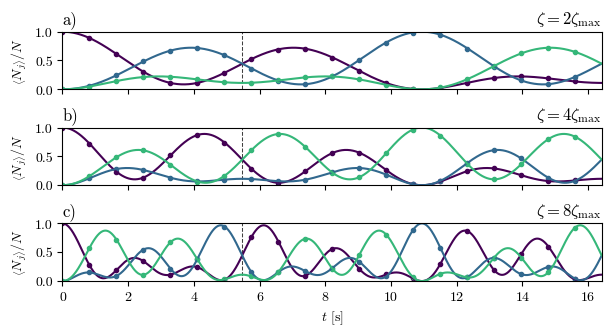

In [ ]:
# Setup axis
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=figsize, layout="constrained")

ax0.axvline(x=tau, linestyle="dashed", linewidth=.75, alpha=.75, color="black")
ax1.axvline(x=tau, linestyle="dashed", linewidth=.75, alpha=.75, color="black")
ax2.axvline(x=tau, linestyle="dashed", linewidth=.75, alpha=.75, color="black")

ax0.set_xlim(min_t, max_t)
ax1.set_xlim(min_t, max_t)
ax2.set_xlim(min_t, max_t)

ax0.set_ylim(0.0, 1.0)
ax1.set_ylim(0.0, 1.0)
ax2.set_ylim(0.0, 1.0)

ax0.set_ylabel(r"$\left\langle N_{j}\right\rangle /N$")
ax1.set_ylabel(r"$\left\langle N_{j}\right\rangle /N$")
ax2.set_ylabel(r"$\left\langle N_{j}\right\rangle /N$")


# A little bit more rotation
params.zeta = 2.0 * zeta_max

# Analytical
N1_value, N2_value, N3_value = get_effective_dynamics(params, time_data)

ax0.plot(time_space, N1_value)
ax0.plot(time_space, N2_value)
ax0.plot(time_space, N3_value)

# Numerical
N1_value, N2_value, N3_value, N4_value = get_dynamics(params, basis_data, time_data)
ax0.scatter(time_space[0:-1:50], N1_value[0:-1:50], marker=".")
ax0.scatter(time_space[0:-1:50], N2_value[0:-1:50], marker=".")
ax0.scatter(time_space[0:-1:50], N3_value[0:-1:50], marker=".")

ax0.set_title("a)", loc="left")
ax0.set_title(r"$\zeta=2\zeta_{\text{max}}$", loc="right")


# Some more extra rotation
params.zeta = 4.0 * zeta_max

# Analytical
N1_value, N2_value, N3_value = get_effective_dynamics(params, time_data)

ax1.plot(time_space, N1_value)
ax1.plot(time_space, N2_value)
ax1.plot(time_space, N3_value)

# Numerical
N1_value, N2_value, N3_value, N4_value = get_dynamics(params, basis_data, time_data)
ax1.scatter(time_space[0:-1:50], N1_value[0:-1:50], marker=".")
ax1.scatter(time_space[0:-1:50], N2_value[0:-1:50], marker=".")
ax1.scatter(time_space[0:-1:50], N3_value[0:-1:50], marker=".")

ax1.set_title("b)", loc="left")
ax1.set_title(r"$\zeta=4\zeta_{\text{max}}$", loc="right")


# Too much rotation!
params.zeta = 8.0 * zeta_max

# Analytical
N1_value, N2_value, N3_value = get_effective_dynamics(params, time_data)

ax2.plot(time_space, N1_value)
ax2.plot(time_space, N2_value)
ax2.plot(time_space, N3_value)

# Numerical
N1_value, N2_value, N3_value, N4_value = get_dynamics(params, basis_data, time_data)
ax2.scatter(time_space[0:-1:50], N1_value[0:-1:50], marker=".")
ax2.scatter(time_space[0:-1:50], N2_value[0:-1:50], marker=".")
ax2.scatter(time_space[0:-1:50], N3_value[0:-1:50], marker=".")

ax2.set_title("c)", loc="left")
ax2.set_title(r"$\zeta=8\zeta_{\text{max}}$", loc="right")
ax2.set_xlabel(r"$t$ [s]")

# Save figure
plt.savefig("../images/plots/pop_dynamics_with_too_much_rotation", dpi=500)

Population imbalance as a function of rotation

/tmp/ipykernel_42466/3509548851.py:25: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax0 = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=(figsize_x, figsize_y / 2), layout="constrained")


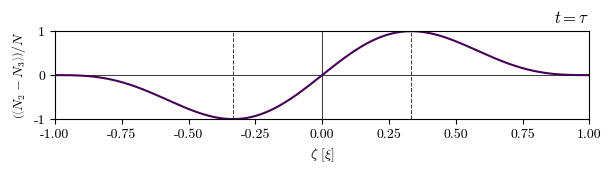

In [ ]:
def get_imbalance(x_space: list, t: float, xi: float) -> list:
    A = 2.0 / 3.0 / np.sqrt(3.0)
    return [A * (np.sin(2.0 * x * t) - 2.0 * np.sin(x * t) * np.cos(xi * t)) for x in x_space]

# Setup parameters
params = ParameterData(0.0, J, 0.0, 0.0, N)
params.set_interaction_ratios(DY_RESONANT_INT_RATIO, DEFAULT_NU_RATIO)

# Resonant period
xi = 1.0
tau = np.pi / xi
zeta_max = xi / 3.0

min_zeta = -3 * zeta_max
max_zeta = 3 * zeta_max
zeta_space = np.linspace(min_zeta, max_zeta, 1000)

# Setup colors and fonts
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(np.linspace(0, 1, 4)))
plt.rcParams["font.family"] = "cmr10"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.unicode_minus"] = False

# Setup axis 
fig, ax0 = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=(figsize_x, figsize_y / 2), layout="constrained")

ax0.set_xlim(min_zeta, max_zeta)
ax0.set_ylim(-1.0, 1.0)

ax0.set_xlabel(r"$\zeta$ [$\xi$]")
ax0.set_ylabel(r"$\left( \left\langle N_{2} - N_{3} \right\rangle \right) /N$")

ax0.axvline(x=zeta_max, linestyle="dashed", linewidth=.75, alpha=.75, color="black")
ax0.axvline(x=-zeta_max, linestyle="dashed", linewidth=.75, alpha=.75, color="black")

ax0.axvline(x=0, linewidth=.75, alpha=.75, color="black")
ax0.axhline(y=0, linewidth=.75, alpha=.75, color="black")

ax0.set_title(r"$t=\tau$", loc="right")

# Plot imbalance
imbalance = get_imbalance(zeta_space, tau, xi)
ax0.plot(zeta_space, imbalance)

# Save figure
plt.savefig("../images/plots/pop_dynamics_with_rotation_diff", dpi=500)

/tmp/ipykernel_42466/2850257664.py:26: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax0 = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=figsize, layout="constrained")
/tmp/ipykernel_42466/2850257664.py:53: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  sub_ax = inset_axes(parent_axes=ax0,width="50%",height="50%",loc="upper center",borderpad=1)


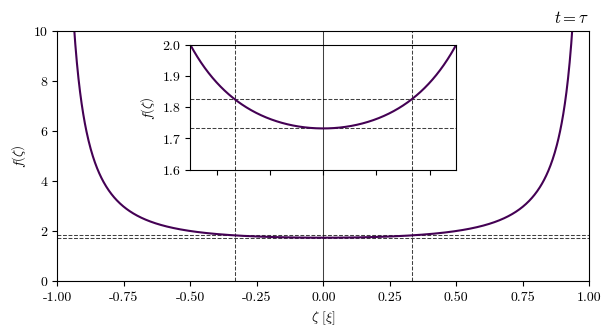

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def get_f_of_zeta(x_space: list, xi: float) -> list:
    return [np.sqrt(2.0 + np.cos(np.pi * x / xi)) / np.cos(np.pi * x / xi / 2.0) for x in x_space]

# Setup parameters
params = ParameterData(0.0, J, 0.0, 0.0, N)
params.set_interaction_ratios(DY_RESONANT_INT_RATIO, DEFAULT_NU_RATIO)

# Resonant period
xi = 1.0
tau = np.pi / xi
zeta_max = xi / 3.0

min_zeta = -3 * zeta_max
max_zeta = 3 * zeta_max
zeta_space = np.linspace(min_zeta, max_zeta, 1000)

# Setup colors and fonts
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(np.linspace(0, 1, 4)))
plt.rcParams["font.family"] = "cmr10"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.unicode_minus"] = False

# Setup axis
fig, ax0 = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=figsize, layout="constrained")

ax0.set_xlim(min_zeta, max_zeta)
ax0.set_ylim(-0.0, 10.0)

ax0.set_xlabel(r"$\zeta$ [$\xi$]")
ax0.set_ylabel(r"$f\left( \zeta \right)$")

ax0.axvline(x=zeta_max, linestyle="dashed", linewidth=.75, alpha=.75, color="black")
ax0.axvline(x=-zeta_max, linestyle="dashed", linewidth=.75, alpha=.75, color="black")

ax0.axhline(y=np.sqrt(3.0), linestyle="dashed", linewidth=.75, alpha=.75, color="black")
ax0.axhline(y=np.sqrt(10.0 / 3.0), linestyle="dashed", linewidth=.75, alpha=.75, color="black")

ax0.axvline(x=0, linewidth=.75, alpha=.75, color="black")
ax0.axhline(y=0, linewidth=.75, alpha=.75, color="black")

ax0.set_title(r"$t=\tau$", loc="right")

# Plot f of zeta
f_of_zeta = get_f_of_zeta(zeta_space, xi)
ax0.plot(zeta_space, f_of_zeta)

min_z = -1.5 * zeta_max
max_z = 1.5 * zeta_max
z_space = np.linspace(min_z, max_z, 1000)

sub_ax = inset_axes(parent_axes=ax0,width="50%",height="50%",loc="upper center",borderpad=1)

sub_ax.set_xlim(min_z, max_z)
sub_ax.set_ylim(1.6, 2.0)

sub_ax.set(xticklabels=[])
sub_ax.set_ylabel(r"$f\left( \zeta \right)$")

sub_ax.axvline(x=zeta_max, linestyle="dashed", linewidth=.75, alpha=.75, color="black")
sub_ax.axvline(x=-zeta_max, linestyle="dashed", linewidth=.75, alpha=.75, color="black")

sub_ax.axhline(y=np.sqrt(3.0), linestyle="dashed", linewidth=.75, alpha=.75, color="black")
sub_ax.axhline(y=np.sqrt(10.0 / 3.0), linestyle="dashed", linewidth=.75, alpha=.75, color="black")

sub_ax.axvline(x=0, linewidth=.75, alpha=.75, color="black")
sub_ax.axhline(y=0, linewidth=.75, alpha=.75, color="black")

# Smaller plot of f of zeta
f_of_zeta = get_f_of_zeta(z_space, xi)
sub_ax.plot(z_space, f_of_zeta)

# Save figure
plt.savefig("../images/plots/f_of_zeta", dpi=500)